In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, f1_score

print("Loading 20 Newsgroups dataset...")
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes")
)

print("Dataset loaded successfully.")
print("Number of training documents:", len(train_data.data))
print("Number of testing documents:", len(test_data.data))
print("Number of categories:", len(train_data.target_names))

Loading 20 Newsgroups dataset...
Dataset loaded successfully.
Number of training documents: 11314
Number of testing documents: 7532
Number of categories: 20


In [3]:
X_train_text = train_data.data
y_train = train_data.target
X_test_text = test_data.data
y_test = test_data.target

print("\nText and labels separated successfully.")


Text and labels separated successfully.


In [4]:
print("\nConverting text into numerical features...")
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=10000
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Text preprocessing completed.")
print("Number of features:", X_train.shape[1])


Converting text into numerical features...
Text preprocessing completed.
Number of features: 10000


In [5]:
print("\nTraining Multinomial Naïve Bayes...")
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
f1_mnb = f1_score(y_test, y_pred_mnb, average="weighted")

print("Multinomial Naïve Bayes completed.")
print("Accuracy:", f"{accuracy_mnb:.4f}")
print("F1-score:", f"{f1_mnb:.4f}")


Training Multinomial Naïve Bayes...
Multinomial Naïve Bayes completed.
Accuracy: 0.6280
F1-score: 0.6117


In [6]:
print("\nTraining Bernoulli Naïve Bayes...")
bnb = BernoulliNB()
bnb.fit(X_train, y_train)

y_pred_bnb = bnb.predict(X_test)

accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
f1_bnb = f1_score(y_test, y_pred_bnb, average="weighted")

print("Bernoulli Naïve Bayes completed.")
print("Accuracy:", f"{accuracy_bnb:.4f}")
print("F1-score:", f"{f1_bnb:.4f}")


Training Bernoulli Naïve Bayes...
Bernoulli Naïve Bayes completed.
Accuracy: 0.5039
F1-score: 0.5104


In [7]:
print("\nModel Comparison")
print("----------------")
print(
    f"Multinomial NB-> Accuracy: {accuracy_mnb:.4f}, "
    f"F1-score: {f1_mnb:.4f}"
)
print(
    f"Bernoulli NB -> Accuracy: {accuracy_bnb:.4f}, "
    f"F1-score: {f1_bnb:.4f}"
)

if accuracy_mnb > accuracy_bnb:
    print("\nBased on accuracy, Multinomial Naïve Bayes performs better.")
elif accuracy_bnb > accuracy_mnb:
    print("\nBased on accuracy, Bernoulli Naïve Bayes performs better.")
else:
    print("\nBoth models have the same accuracy.")


Model Comparison
----------------
Multinomial NB-> Accuracy: 0.6280, F1-score: 0.6117
Bernoulli NB -> Accuracy: 0.5039, F1-score: 0.5104

Based on accuracy, Multinomial Naïve Bayes performs better.


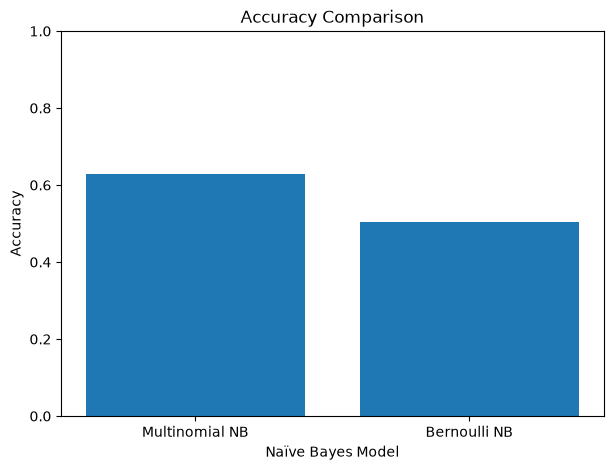

In [8]:
models = ["Multinomial NB", "Bernoulli NB"]
accuracies = [accuracy_mnb, accuracy_bnb]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)
plt.xlabel("Naïve Bayes Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

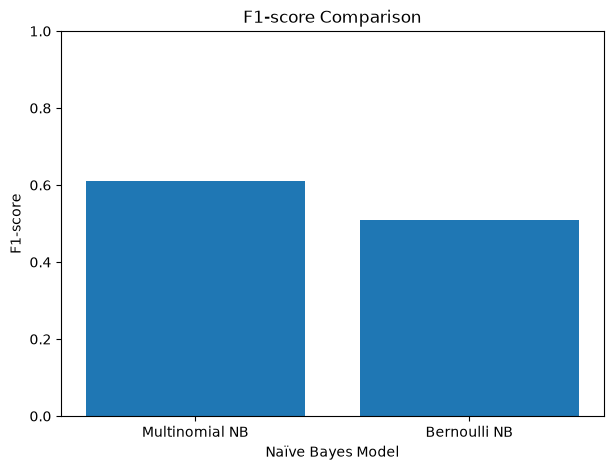

In [9]:
f1_scores = [f1_mnb, f1_bnb]

plt.figure(figsize=(7, 5))
plt.bar(models, f1_scores)
plt.xlabel("Naïve Bayes Model")
plt.ylabel("F1-score")
plt.title("F1-score Comparison")
plt.ylim(0, 1)
plt.show()